In [78]:
using MarineHydro
import Meshes as Meshes
using CairoMakie: CairoMakie as Makie
using Unitful: m, ustrip, Length, u, @u_str
using LinearAlgebra: cross, dot, norm, diag
using DifferentiationInterface 
import ForwardDiff 
using FiniteDifferences
using Test

In [79]:
function generate_lid(x_min_lid::Real, x_max_lid::Real, y_min_lid::Real, y_max_lid::Real, z_value::Real, faces_max_radius::Real, show_lid::Bool=false)

    n_panels_x = Int(ceil((x_max_lid-x_min_lid)/(2*faces_max_radius)))
    n_panels_y = Int(ceil((y_max_lid-y_min_lid)/(2*faces_max_radius)))

    mesh = rectangular_lid_mesh(x_min_lid, x_max_lid, y_min_lid, y_max_lid, n_panels_x, n_panels_y, z_value)
    if show_lid
        fig = Makie.Figure()
        ax = Makie.Axis3(fig[1, 1], title = "Rectangular Lid Mesh", aspect = :data)
        Meshes.viz!(ax, mesh, color=:gold, showsegments=true, segmentcolor=:grey50, segmentsize=0.25)
        display(fig)
    end
    return Mesh(mesh)
end


function generate_lid(x_min_lid::Real, x_max_lid::Real, y_min_lid::Real, y_max_lid::Real, z_value::Real, faces_max_radius::Real)
    return generate_lid(x_min_lid, x_max_lid, y_min_lid, y_max_lid, z_value, faces_max_radius, false)
end


function arbitrary_axisymmetric_mesh(x::Vector, n_theta, n_bottom, show_plot)

    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)

    z_side = collect(range(-0.0, -draft, length=n_side))

    panel_z_len = abs(z_side[1]-z_side[2])
    last_z = z_side[end]

    z_bottom = ones(n_bottom) * (-draft)
    r_bottom = collect(range(r_side[end], 0.0, length=n_bottom+1))[2:end]

    z_vals = vcat(z_side, z_bottom)
    r_vals = vcat(r_side, r_bottom)

    MH_mesh = axisymmetric_mesh(r_vals,z_vals,n_theta,show_plot)

    return MH_mesh
end

function generate_lid_for_axisymmetric_geom(x, show_lid)

    # fixed parameters
    x_mean = 0.0
    y_mean = 0.0
    reduce_scale = 0.95
    n_panels_x = 5
    n_panels_y = 5
    z_value = -0.0734083

    # changable parameters
    radius_at_surface = r_side[1]
    width = radius_at_surface * (2/sqrt(2)) * reduce_scale
    x_min_lid = x_mean - width/2
    x_max_lid = x_mean + width/2
    y_min_lid = y_mean - width/2
    y_max_lid = y_mean + width/2   

    mesh = rectangular_lid_mesh(x_min_lid, x_max_lid, y_min_lid, y_max_lid, n_panels_x, n_panels_y, z_value)
    if show_lid
        fig = Makie.Figure()
        ax = Makie.Axis3(fig[1, 1], title = "Rectangular Lid Mesh", aspect = :data)
        Meshes.viz!(ax, mesh, color=:gold, showsegments=true, segmentcolor=:grey50, segmentsize=0.25)
        display(fig)
    end
    return Mesh(mesh)
end

function generate_lid_for_axisymmetric_geom(x_val)
    return generate_lid_for_axisymmetric_geom(x_val, false)
end

function rectangular_lid_mesh(x_min::Real, x_max::Real, y_min::Real, y_max::Real, n_panels_x::Int, n_panels_y::Int, z_value::Real=0.0)
    # 1. Create a flat 2D CartesianGrid
    start_point = Meshes.Point(x_min, y_min)
    end_point   = Meshes.Point(x_max, y_max)
    grid = Meshes.CartesianGrid(start_point, end_point, dims=(n_panels_x, n_panels_y))

    # 2. Extract the 2D vertices and elevate them to 3D
    verts2d = Meshes.vertices(grid)
    verts3d = map(verts2d) do v
        vec_coords = Meshes.to(v)
        z_with_unit = z_value * u"m"
        Meshes.Point(vec_coords[1], vec_coords[2], z_with_unit)
    end

    # 3. Extract the connectivity indices natively from the grid elements
    # This unpacks the quad-panel connections explicitly
    connec = [Meshes.connect(Tuple(e.indices)) for e in Meshes.topology(grid)]

    # 4. Construct the SimpleMesh using an explicit unstructured configuration
    return Meshes.SimpleMesh(verts3d, connec)
end

function arbitrary_axisymmetric_mesh(x)
    return arbitrary_axisymmetric_mesh(x, 20, 3, false)
end


function hydrostatic_program(x)
    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)
    
    z_side = range(-1e-3, -draft, length=n_side)

    rho_w = 1025.0 
    g = 9.81 
    K = rho_w * g * pi * r_side[1]^2 


    volume = 0.0
    for i in 1:(n_side-1)
        h_mid = abs(z_side[i] - z_side[i+1])
        r1 = r_side[i]
        r2 = r_side[i+1]

        volume += (pi * h_mid / 3) * (r1^2 + r1 * r2 + r2^2)
    end
    
    M = rho_w * volume 

    return [M, K]
end

hydrostatic_program (generic function with 1 method)

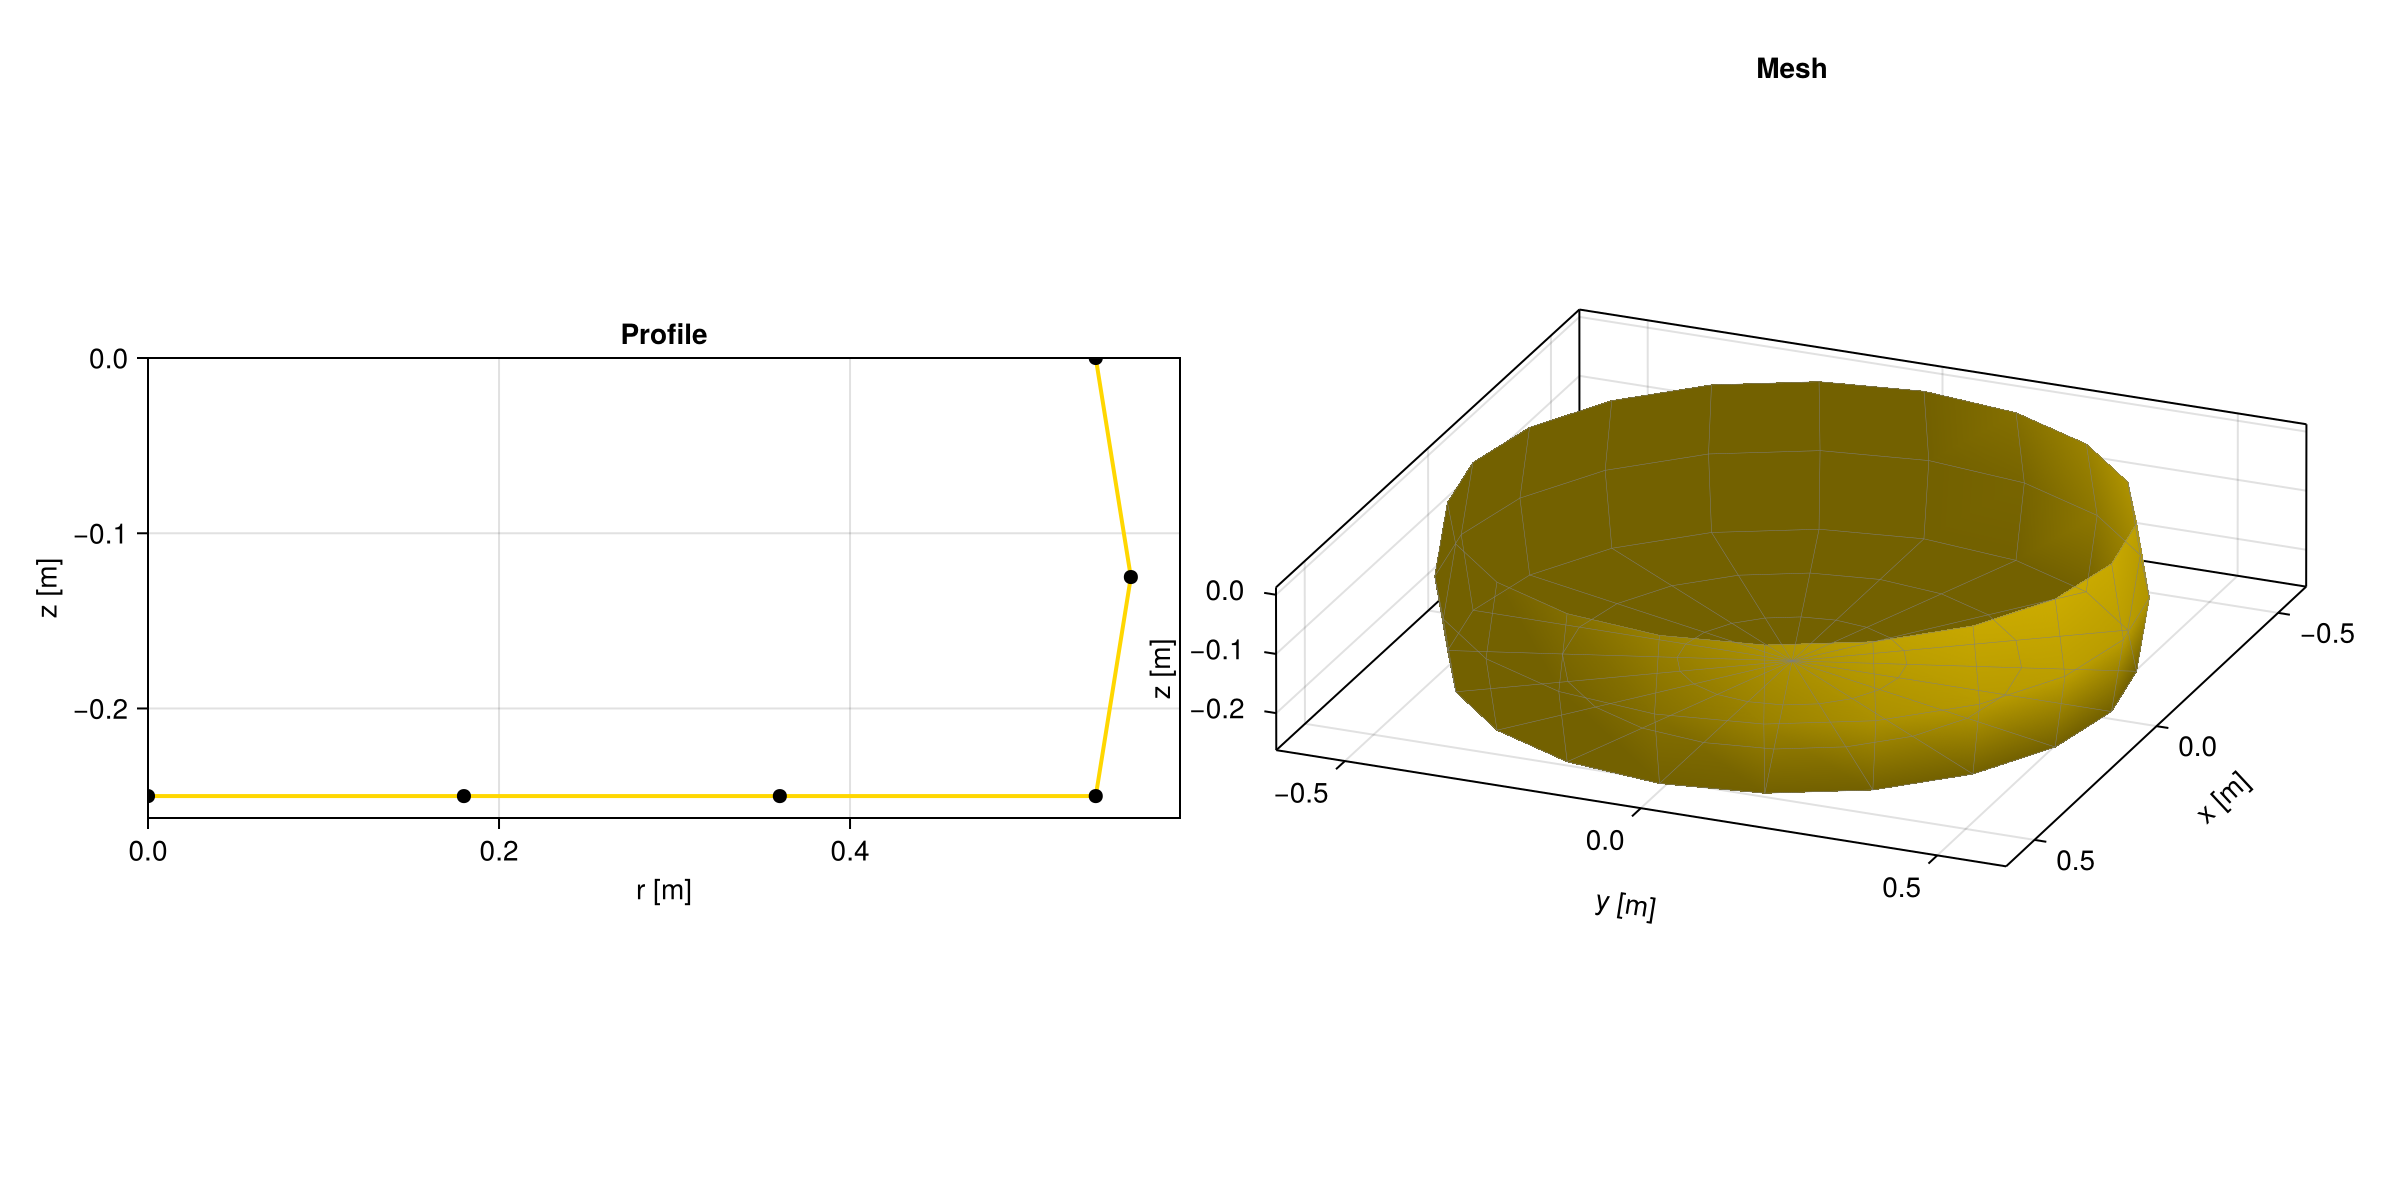

Mesh([0.54 0.0 0.0; 0.513570518799383 0.1668691769624716 0.0; … ; 0.17119017293312763 -0.05562305898749057 -0.25; 0.0 0.0 -0.25], [0 20 21 1; 1 21 22 2; … ; 98 100 99 99; 99 100 80 80], Number[0.5365996649059035 0.08498903760445524 -0.06287878787878787; 0.48407355099520727 0.24664779365919723 -0.06287878787878787; … ; 0.10560441064020604 -0.05380813480004526 -0.25; 0.11706339097770921 -0.01854101966249686 -0.25], Number[0.97558160638978 0.15451694671895766 0.15609305702236495; 0.8800848814796082 0.4484256448291479 0.15609305702236448; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.02177666965441897, 0.021776669654418972, 0.021776669654418976, 0.02177666965441897, 0.02177666965441897, 0.02177666965441897, 0.021776669654418976, 0.02177666965441897, 0.021776669654418976, 0.02177666965441897  …  0.005006075308874141, 0.005006075308874154, 0.0050060753088741455, 0.005006075308874149, 0.005006075308874147, 0.005006075308874148, 0.005006075308874147, 0.005006075308874148, 0.005006075308874149, 0.0050060

In [80]:
radii_upper = 1.0
radii_lower = 0.1
draft_upper = 2.0
draft_lower = 0.25

r_initial = 0.5
n_side = 4-1 # number of design vars-1 (draft is also a design var)

# inputs
# r_side = ones(n_side) * r_initial
# r_side = collect(range(0.5, 0.001, length=n_side)) # last radius cannot be zero
# rad_ref = (radii_upper+radii_lower)/2 * 0.75
# r_side = collect(range(rad_ref*1.1, rad_ref*0.9, length=n_side))
# draft = draft_lower
# r_side = ones(n_side) * (radii_upper+radii_lower)/2 * 0.75
# draft = draft_upper
# r_side = ones(n_side) * radii_upper
radii_nom = (radii_lower+radii_upper)/2
r_side = radii_nom * ones(n_side)
draft_nom = (draft_lower+draft_upper)/2
# draft=draft_nom
draft=draft_lower

purt=1e-2
r_side += [(-1)^(i) for i in 1:n_side]*purt

x_val = vcat(r_side,draft)

# add perturbation to prevent vertical panels
 



ax_mesh = arbitrary_axisymmetric_mesh(x_val, 20, 3, true)

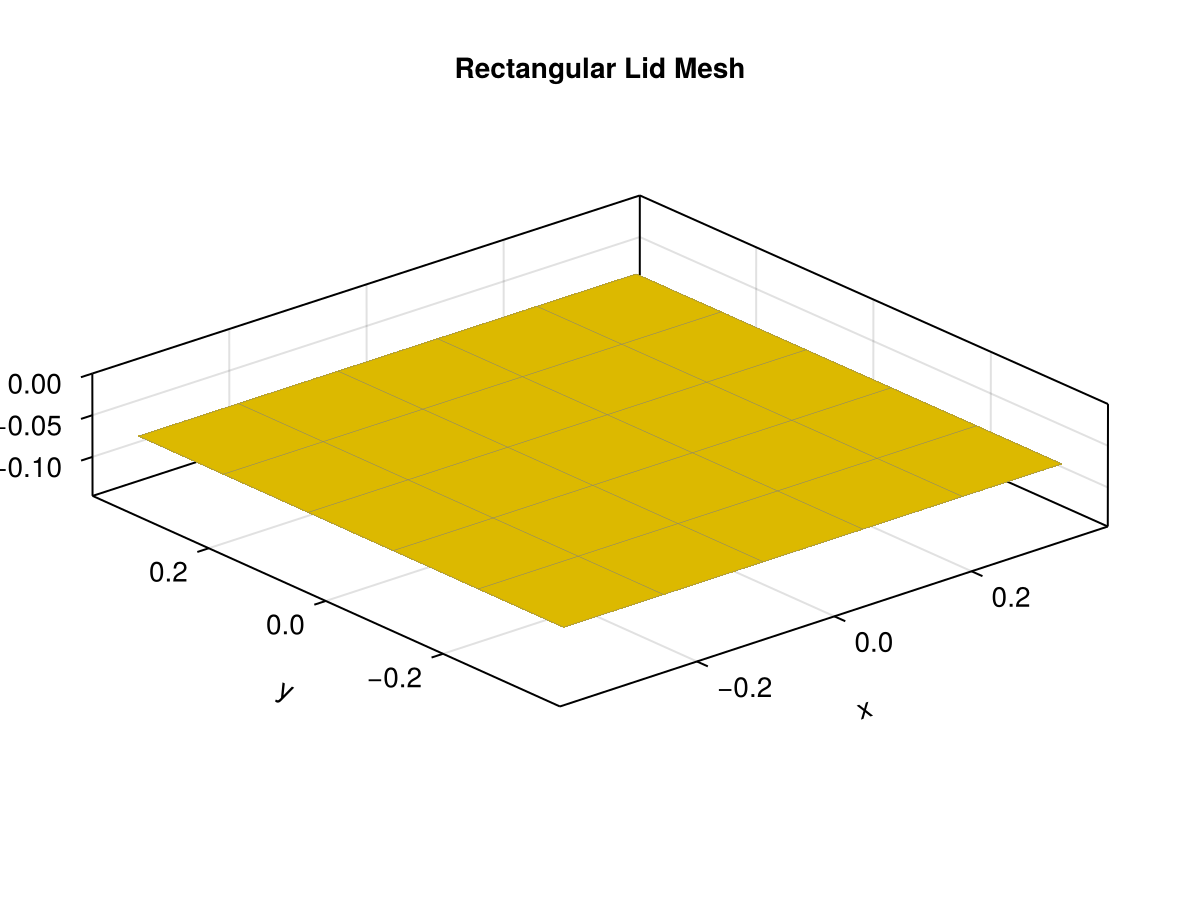

Mesh([-0.36274577874869884 -0.36274577874869884 -0.0734083; -0.2176474672492193 -0.36274577874869884 -0.0734083; … ; 0.21764746724921935 0.36274577874869884 -0.0734083; 0.36274577874869884 0.36274577874869884 -0.0734083], [0 1 7 6; 1 2 8 7; … ; 27 28 34 33; 28 29 35 34], Number[-0.2901966229989591 -0.2901966229989591 -0.0734083; -0.14509831149947955 -0.2901966229989591 -0.0734083; … ; 0.14509831149947958 0.29019662299895915 -0.0734083; 0.2901966229989591 0.2901966229989591 -0.0734083], Number[0.0 0.0 1.0; 0.0 0.0 1.0; … ; 0.0 0.0 1.0; 0.0 0.0 1.0], [0.02105352, 0.02105352, 0.02105352, 0.02105352, 0.021053519999999992, 0.02105352, 0.02105352, 0.02105352, 0.02105352, 0.021053519999999992  …  0.02105352, 0.02105352, 0.02105352, 0.02105352, 0.021053519999999992, 0.021053519999999992, 0.021053519999999992, 0.021053519999999992, 0.021053519999999992, 0.021053519999999982], Number[0.10260000000000004, 0.10260000000000004, 0.10260000000000001, 0.10260000000000004, 0.10260000000000004, 0.102600

In [81]:
show_lid=true
lid_mesh = generate_lid_for_axisymmetric_geom(x_val, show_lid)

In [82]:
# Compute function to verify jacobian


function compute_vals(x, omegas)
    set_rho!(1025.0)
    mesh = arbitrary_axisymmetric_mesh(x)    
    M_val, K_val = hydrostatic_program(x)

    betas = [0.0]
    rigid_dof_list = ["Heave"]
    rotation_center = [0.0,0.0,0.0]

    parameters = (wave_frequencies=omegas, 
        wave_directions=betas,
        radiating_dofs=Symbol.(rigid_dof_list),
        influenced_dofs=Symbol.(rigid_dof_list))

    # Method
    direct=true

    # Green's function
    gf="Wu"

    lid_mesh = generate_lid_for_axisymmetric_geom(x, false)
    floatingbody = FloatingBody(mesh, lid_mesh, rigid_dof_list, rotation_center, "axisymmetric_fb_with_lid")
    
    data = compute_hydrodynamic_coefficients(parameters, floatingbody, direct=direct, gf=gf)
    
    # results = solve_all_problems(problems; direct=direct, gf=gf)
    # data = assemble_hydrodynamic_coefficients(parameters, floatingbody, results)
    # # Output
    # # mhresults = compute_hydrodynamic_coefficients(parameters, floatingbody_with_lid, direct=direct, gf=gf)
    # problems = problems_from_data(parameters, floatingbody)
    # # focus on added mass
    # problem = problems[2]


    # # Apply boundary conditions 
    # bc_on_hull = vec(compute_bc(problem)) 

    # # Specify omega and wavenumber based on forward speed 
    # if problem.forward_speed==0
    #     omega = problem.omega
    #     wavenumber = problem.wavenumber
    # else
    #     omega = problem.encountered_omega
    #     wavenumber = problem.encountered_wavenumber # use encountered_wavenumber in gfs
    # end

    # # Select a Greens function
    # if gf=="Wu"  
    #     selected_GF = GFWu()
    # elseif gf=="ExactGuevelDelhommeau"
    #     selected_GF = ExactGuevelDelhommeau()
    # end

    # # combine mesh and lid_mesh and define bc accordingly
    # if isnothing(problem.floatingbody.lid_mesh)
    #     mesh_including_lid = problem.floatingbody.mesh
    #     hull_mask = trues(mesh_including_lid.nfaces)
    # else
    #     mesh_including_lid = problem.floatingbody.mesh + problem.floatingbody.lid_mesh 
    #     hull_mask = eachrow(mesh_including_lid.faces) .∈ Ref(eachrow(problem.floatingbody.mesh.faces))
    # end
    
    # bc = zeros(eltype(bc_on_hull), mesh_including_lid.nfaces)
    # bc[hull_mask] = bc_on_hull

    # Create influneced matrices (include lid)
    # S, D = assemble_matrices([Rankine(), RankineReflected(), selected_GF], mesh_including_lid, wavenumber; direct=direct)

    # τ̅ = 2π
    # green_functions=[Rankine(), RankineReflected(), selected_GF]
    # mesh=mesh_including_lid
    # all_normals=nothing
    
    # free_surface = 0.0

    # if eltype(mesh.vertices)<: ForwardDiff.Dual
    #     T = eltype(mesh.vertices)
    # else
    #     T = eltype(wavenumber)
    # end

    # # S = @inbounds [-1/2τ̅ * Complex{T}(integral(green_functions, element(mesh, i), element(mesh, j), wavenumber)) for i in 1:mesh.nfaces, j in 1:mesh.nfaces]

    # D = @inbounds [begin
    #         element_i = element(mesh, i)
    #         element_j = element(mesh, j)

    #         n = direct ? normal(element_j) : normal(element_i)
        
    #         # if not forward speed problem, just 1
    #         dot_prod_fs = isnothing(all_normals) ? Complex{T}(1.0, 0.0) : n' * all_normals                      

    #         c = i == j ? Complex{T}(1.0, 0.0) : Complex{T}(0.0, 0.0) # if diagonal

    #         constant = abs(mesh.centers[i,3]-free_surface) < 1e-8 ? c : c/2 # if panel on surface

    #         # (n' * norm_vec)=1 when n==panel normal vector. When all_normals is provided (for forward speed problems), this is not always the case.
    #         (constant * dot_prod_fs) - 1/2τ̅ * Complex{T}(n' * integral_gradient(green_functions, element_i, element_j, wavenumber; with_respect_to_first_variable=!direct))
    #     end for i in 1:mesh.nfaces, j in 1:mesh.nfaces]

    # # first element of D_matrix
    # τ̅ = 2π
    # i=1
    # j=2
    # element_i = element(mesh, i)
    # element_j = element(mesh, j)

    # n = direct ? normal(element_j) : normal(element_i)

    # # if not forward speed problem, just 1
    # dot_prod_fs = isnothing(all_normals) ? Complex{T}(1.0, 0.0) : n' * all_normals                      

    # c = i == j ? Complex{T}(1.0, 0.0) : Complex{T}(0.0, 0.0) # if diagonal

    # constant = abs(mesh.centers[i,3]-free_surface) < 1e-8 ? c : c/2 # if panel on surface

    # # (n' * norm_vec)=1 when n==panel normal vector. When all_normals is provided (for forward speed problems), this is not always the case.
    # # p1 = (constant * dot_prod_fs) - 1/2τ̅ 
    # # p2 = Complex{T}(n' * integral_gradient(green_functions, element_i, element_j, wavenumber; with_respect_to_first_variable=!direct))
    # # D_el = p1 * p2
    # # int_grad_vec = integral_gradient(green_functions, element_i, element_j, wavenumber; with_respect_to_first_variable=!direct)
    
    # # int_grad_vec = gradient_greens(g::GFWu, element_1, element_2, wavenumber; with_respect_to_first_variable) * area(element_2)
    # element_1_temp=element_i
    # element_2=element_j

    # # output = both_greens_and_gradient_greens(green_functions[3], element_1, element_2, wavenumber; with_respect_to_first_variable=false)
    # # vec_out = output[2]

    # # area_val = area(element_2)

    # # int_grad_vec = vec_out * area_val

    # # int_grad_vec = integral_gradient(green_functions[2], element_i, element_j, wavenumber; with_respect_to_first_variable=!direct)
    
    # # ref_e1 = free_surface_symmetry(element_1)
    # # output = vertices(ref_e1)

    # # int_grad_vec = integral_gradient(Rankine(), free_surface_symmetry(element_1), element_2; with_respect_to_first_variable=!direct)

    # element_1 = free_surface_symmetry(element_1_temp)
    # # element_1 = element_1_temp

    # point = center(element_1)
    # point_vertices = vertices(element_1)
    # source_point = center(element_2)
    # source_vertices = vertices(element_2)
    # source_normal = normal(element_2)
    # source_radius = radius(element_2)
    # source_area = area(element_2)
    # r̄ = point - source_point
    # r = norm(r̄)

    # _distance(x, ξ) = norm(x .- ξ)

    # segment_lengths = zero(r)

    # integral = zero(source_area)
    # integral_gradient = zero(point)
    # GZ = dot(r̄, source_normal)



    # # Must make abs(GZ) and sign(GZ) differentiable if GZ==0
    # function diffable_abs(x, purt)
    #     abs_val = sqrt(x^2 + purt^2)
    #     return abs_val
    # end
    # function diffable_sign(x, purt)
    #     sign_val = x/diffable_abs(x, purt)
    #     return sign_val
    # end

    # # Absolute value
    # purt1 = 1e-18 # can get away with smaller value since 
    # # deriv of abs at 0 using central dif is zero regardless of purt
    # GZ_abs = diffable_abs(GZ, purt1) 

    # # Sign
    # purt2 = 1e-5 # may need to change
    # GZ_sign = diffable_sign(GZ, purt2)
    # # noticable error when -5*put2<GZ< 5*purt2
    # # want GZ during finite difference about GZ=0 to be in this range 
    # # Otherwise, do not want to be in this range. In future consider
    # # changing purt2 based on mesh size of problem.


    # # println("r̄: $r̄")
    # # println("GZ $GZ")
    # # println("point $point")
    # # println("source_point $source_point")
    




    # RR = ntuple(i -> _distance(point, source_vertices[i,:]), 4)
    # DRX = ntuple(i -> (point - source_vertices[i,:]) / RR[i], 4)
    # for index_vertex in 1:4
    #     current_vertex = source_vertices[index_vertex,:]
    #     index_next_vertex = mod1(index_vertex+1, 4)
    #     next_vertex = source_vertices[index_next_vertex, :]
    #     current_to_next = next_vertex - current_vertex
    #     segment_length = norm(current_to_next)

    #     segment_lengths = segment_lengths + segment_length
    #     # source_radii[index_vertex] = source_radius

    #     if segment_length >= 1e-3 * source_radius
    #         GYX = cross(source_normal, current_to_next / segment_length)
    #         GY = dot(point - current_vertex, GYX)
    #         ANT = 2 * GY * segment_length
    #         DNT = (RR[index_next_vertex] + RR[index_vertex])^2 - segment_length^2 +
    #             2 * GZ_abs * (RR[index_next_vertex] + RR[index_vertex])
    #         ANL = RR[index_next_vertex] + RR[index_vertex] + segment_length
    #         DNL = RR[index_next_vertex] + RR[index_vertex] - segment_length
    #         ALDEN = log(ANL / DNL)

    #         # GZs[index_vertex] = GZ

    #         if GZ_abs >= 1e-4 * source_radius
    #             AT = atan(ANT, DNT)  #check difference
    #         else
    #             AT = zero(ANT)
    #         end
    #         #error bound error in the line below...
    #         ANLX = DRX[index_next_vertex] + DRX[index_vertex]
    #         ANTX = 2 * segment_length * GYX
    #         DNTX = 2 * (RR[index_next_vertex] + RR[index_vertex] + GZ_abs) * ANLX +
    #             2 * GZ_sign * (RR[index_next_vertex] + RR[index_vertex]) * source_normal

    #         integral += GY * ALDEN
    #         integral_gradient = integral_gradient .-
    #                                 (ALDEN .* GYX .- 2 * GZ_sign * AT .* source_normal .+
    #                                 GY * (DNL - ANL) ./ (ANL .* DNL) .* ANLX .-
    #                                 2 * GZ_abs .* (ANTX .* DNT .- DNTX .* ANT) ./ (ANT .* ANT .+ DNT .* DNT))
    #     end
    # end

    # int_grad_vec = integral_gradient



    # # Solve linear system (include lid)
    # potential, sources = solve(D, S, bc; direct=direct)

    # # Compute pressure (include lid)
    # pressure = 1im * SETTINGS.rho * omega * potential # uses encountered_omega

    # # Slice pressure (excludes lid)
    # pressure_on_hull = pressure[hull_mask]

    # if problem.forward_speed!=0
    #     # change normals to all be unit vector in x direction
    #     S, D = assemble_matrices([Rankine(), RankineReflected(), selected_GF], mesh_including_lid, wavenumber; direct=direct, all_normals=[1,0,0])
    #     if direct
    #         error("MarineHydro.jl has yet to be developed for nonzero forward speeds 
    #         with the direct method. Try changing direct to false.")
    #         # partial_phi_partial_x = S \ (D * potential)
    #         # sources = S \ potential          
    #         # partial_phi_partial_x = K * sources
    #     else
    #         K = D
    #         partial_phi_partial_x = K * sources
    #     end
    #     additional_pressure = SETTINGS.rho * problem.forward_speed * partial_phi_partial_x
    #     pressure_on_hull .+= additional_pressure[hull_mask]
    # end

    # forces = integrate_pressure(problem.floatingbody, problem.influenced_dofs, pressure_on_hull) # NamedTuple of complex forces, where each element corresponds to an influenced dof 
    # force_val = forces[:Heave]



    # results = solve_all_problems(problems; direct=direct, gf=gf)
    # data = assemble_hydrodynamic_coefficients(parameters, floatingbody, results)
    # real(.(diag(D)))

    #vcat(real.(int_grad_vec),imag.(int_grad_vec))

    # segment_lengths = zeros(4)
    # GZs = zeros(4)
    # source_radii = zeros(4)
    # [GZ_abs, GZ_sign]
    #vcat(data.added_mass[1,:,:,:],data.radiation_damping[1,:,:,:],real.(data.diffraction_force[1,:,:,:]),imag.(data.diffraction_force[1,:,:,:]))

    return vcat(data.added_mass[1,1,1,1],data.radiation_damping[1,1,1,1],real.(data.diffraction_force[1,1,1,1]),imag.(data.diffraction_force[1,1,1,1]))

end
    

compute_vals (generic function with 1 method)

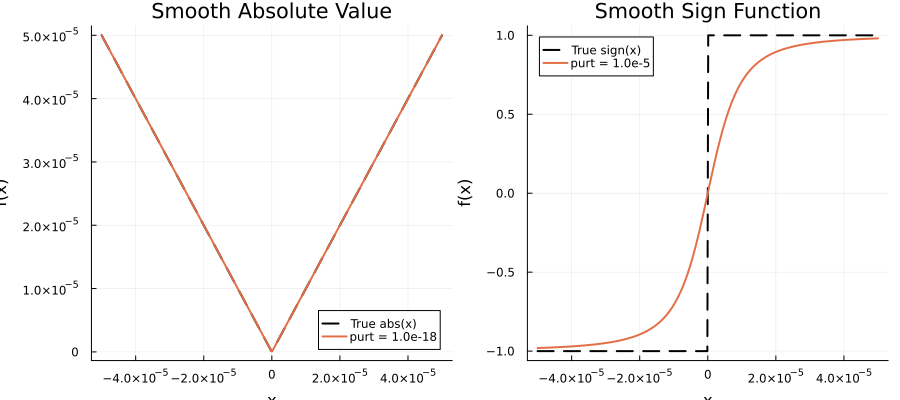

In [83]:
import Plots as Plots

function diffable_abs(x, purt)
    return sqrt(x^2 + purt^2)
end
function diffable_sign(x, purt)
    return x/diffable_abs(x, purt)
end

purt1 = 1e-18 # can get away with smaller value since 
# deriv of abs at 0 using central dif is zero regardless of purt
purt2 = 1e-5

x_vals = range(-5e-5, 5e-5, length=400)

p1 = Plots.plot(x_vals, x -> abs(x), label="True abs(x)", color=:black, linestyle=:dash, linewidth=2)
Plots.plot!(p1, x_vals, x -> diffable_abs(x, purt1), label="purt = $purt1", linewidth=2)
Plots.title!(p1, "Smooth Absolute Value")
Plots.xlabel!(p1, "x")
Plots.ylabel!(p1, "f(x)")

p2 = Plots.plot(x_vals, x -> sign(x), label="True sign(x)", color=:black, linestyle=:dash, linewidth=2)
Plots.plot!(p2, x_vals, x -> diffable_sign(x, purt2), label="purt = $purt2", linewidth=2)
Plots.title!(p2, "Smooth Sign Function")
Plots.xlabel!(p2, "x")
Plots.ylabel!(p2, "f(x)")

# 5. Combine them into a side-by-side layout
Plots.plot(p1, p2, layout=(1, 2), size=(900, 400))

In [84]:
# Verify evaluation
omega = 0.3*2*pi * 2
omegas = [omega]
out = compute_vals(x_val, omegas)

4-element Vector{Float64}:
   275.2056424499543
   355.8613579805252
 -2701.173476346589
 -1453.8048910264213

In [85]:
backend = AutoForwardDiff()
value_and_derivative(x -> sign(x), backend, 0)
# finite difference derivative is nonzero, while AD derivative=0

(1, 0)

In [86]:
value_and_derivative(x -> abs(x), backend, 0)
# finite difference derivative is zero, while AD derivative=1

(0, 1)

In [87]:
# AD
backend = AutoForwardDiff()
AD_v_J = value_and_jacobian(x -> compute_vals(x, omegas), backend, x_val)
AD_J = AD_v_J[2]

# FD
# method = forward_fdm(5, 1; max_range=1e-8)
method = forward_fdm(5, 1)
FD_J = FiniteDifferences.jacobian(method, x -> compute_vals(x, omegas), x_val)[1]


4×4 Matrix{Float64}:
    587.29   168.414    809.467  -143.245
   5023.3   -843.352   -787.66   -968.751
 -11299.6    552.376  -3836.91   6101.93
 -15926.2   1513.52    2218.04   2196.59

In [88]:
@testset "Verify jacobian matrix with finite difference" begin
    n_row = length(FD_J[:,1])
    n_col = length(FD_J[1,:])

    for i in 1:n_row
        for j in 1:n_col
            @testset "Row $i column $j" begin
                @test  AD_J[i,j] ≈ FD_J[i,j] atol=1e-3 rtol = 1e-3
            end
        end
    end
end

Row 1 column 1: Test Failed at c:\Users\15183\wave-to-wire\MarineHydro.jl\dev\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:8
  Expression: ≈(AD_J[i, j], FD_J[i, j], atol = 0.001, rtol = 0.001)
   Evaluated: 583.1912069624644 ≈ 587.2901635309934 (atol=0.001, rtol=0.001)

Stacktrace:
 [1] macro expansion
   @ C:\Users\15183\.julia\juliaup\julia-1.10.10+0.x64.w64.mingw32\share\julia\stdlib\v1.10\Test\src\Test.jl:672 [inlined]
 [2] macro expansion
   @ c:\Users\15183\wave-to-wire\MarineHydro.jl\dev\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:8 [inlined]
 [3] macro expansion
   @ C:\Users\15183\.julia\juliaup\julia-1.10.10+0.x64.w64.mingw32\share\julia\stdlib\v1.10\Test\src\Test.jl:1577 [inlined]
 [4] macro expansion
   @ c:\Users\15183\wave-to-wire\MarineHydro.jl\dev\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X13sZmlsZQ==.jl:8 [inlined]
 [5] macro expansion
   @ C:\Users\15183\.julia\juliaup\julia-1.10.10+0.x64.w64.mingw32\share\julia\stdli

TestSetException: Some tests did not pass: 8 passed, 8 failed, 0 errored, 0 broken.

In [89]:
ii = 1

# AD_J[ii:ii+10,:]
AD_J

4×4 Matrix{Float64}:
    583.191   168.414    813.572  -143.245
   5036.84   -843.352   -801.166  -968.751
 -11230.0     552.376  -3907.01   6101.93
 -15982.7    1513.52    2273.95   2196.59

In [90]:
# FD_J[ii:ii+10,:]
FD_J

4×4 Matrix{Float64}:
    587.29   168.414    809.467  -143.245
   5023.3   -843.352   -787.66   -968.751
 -11299.6    552.376  -3836.91   6101.93
 -15926.2   1513.52    2218.04   2196.59

In [91]:
maximum(abs.(FD_J-AD_J))

70.09415218073718

In [92]:
# potentials wrong
# S matrix correct!

# Derivatives of first 2 diagonal element of D are wrong...
# but some other diagonal elements are correct 
# 
# Only real parts of partial/partial diag(D)
# are incorrect! Partials of imaginary diagonal
# elements are correct... what does this imply?
#
# changing constant = abs(mesh.centers[i,3]-free_surface) < 1e-8 ? does not change sensitivity
# changing dis = sqrt(dis_squared_raw + purt^2) - purt does not change derivative
# changing to dot_prod_fs = isnothing(all_normals) ? Complex{T}(1.0, 0.0) : n' * all_normals did not help
# jacobian of n is correct
# jacobian of dot_prod_fs is correct
# jacobian of  Complex{T}(n' * integral_gradient(green_functions, element_i, element_j, wavenumber; with_respect_to_first_variable=!direct)) is wrong!
# jacobian of real is wrong but imag is correct for integral_gradient 
# jacobian or area is correct
# jacobian of integral_gradient for Wu and Rankine is correct, but incorrect for ReflectedRankine!!!! 
# Issues is either coming from free_surface_symmetry or vertical_reflection
# Jacobian of center(ReflectedElement) is correct 
# Jacobian of normal(ReflectedElement) is correct  
# Jacobian of area(ReflectedElement) is correct 
# Jacobian of radius(ReflectedElement) is correct     
# Jacobian of vertices(ReflectedElement) is correct   
# Jacobian of integral_gradient(Rankine(), free_surface_symmetry(element_1), element_2; with_respect_to_first_variable) incorrect!

# Problem in the else condition of both_integral_and_integral_gradient in rankine.jl
# Changed the way mesh obtains radii (maximum dis from center, not first)

# it is not segment_lengths = zeros(4) GZs = zeros(4)  source_radii = zeros(4) if statements
# the issue is sign and abs of GZ since GZ is zero for som diagonals of D
# jacobian of GZ itself is okay
# Hypothesis, while GZ itself may be zero, the derivative that is 
# tracked with it carries inportant info, and cannot be zeroed. This
# important derivative info comes from the source_normal in
# GZ = dot(r̄, source_normal) changing. 